# The 1% Allocation ₿
### Everyone has a number. Nobody can defend it.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

1%. Or 2%. Or 5%. The recommendations arrive with charts and optimisers and a great deal of
confidence. Here is the awkward part: **feed bitcoin's actual record into an optimiser and it
asks for far more than any of them.** So the published numbers are not what the history says.
This study works out what they *are* saying.

> \U0001F4D3 **This is the plain-language layer.** The bootstrap, the sample-size arithmetic and
> the known-truth control are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Did a bitcoin sleeve help, in hindsight? | Enormously. |
| What weight does the history recommend? | A large double-digit one. |
| So where does "1%" come from? | Not from the history. |
| What does a 2% sleeve assume? | That bitcoin earns roughly nothing. |

> This study set out to show that the data cannot tell 1% from 5%. It found the opposite, and
> the opposite is more interesting: fed bitcoin's actual record, the optimiser recommends far
> **more** than anyone publishes. The published numbers come from overriding the record — which
> is reasonable, and worth saying out loud.

## 1 · A housekeeping step that is not housekeeping

In [2]:
from onepercent import data, strategy as st

px = data.load_prices()
rets = st.align_to_equity_calendar(px, data.EQUITY).pct_change()
base = st.sixty_forty(rets, data.EQUITY, data.BONDS)
btc = rets[data.BTC].dropna()
common = base.index.intersection(btc.index)
base, btc = base.loc[common], btc.loc[common]
print(f"as-of {data.AS_OF} | {len(common):,} common sessions from "
      f"{common[0].date()} ({len(common)/252:.1f} years)")
b = st.stats(base)
print(f"the 60/40 alone: {b['cagr']:.2%} a year, {b['vol']:.1%} vol, "
      f"Sharpe {b['sharpe']:.2f}")

as-of 2026-06-30 | 2,962 common sessions from 2014-09-18 (11.8 years)
the 60/40 alone: 9.31% a year, 10.9% vol, Sharpe 0.85


In [3]:
raw = px[data.BTC].dropna().pct_change().dropna()
v252 = raw.std(ddof=1) * np.sqrt(252)
v365 = raw.std(ddof=1) * np.sqrt(365)
print(f"bitcoin volatility, annualised over 252 trading days: {v252:.1%}")
print(f"                    annualised over 365 calendar days: {v365:.1%}")
print(f"difference: {v365/v252 - 1:.0%}")
print()
print("Bitcoin trades every day; SPY does not. Using 365 for one and 252 for the other")
print("makes bitcoin look better on every risk-adjusted measure. Everything here uses")
print("the equity calendar, with weekend moves folded into Monday.")

bitcoin volatility, annualised over 252 trading days: 55.3%
                    annualised over 365 calendar days: 66.6%
difference: 20%

Bitcoin trades every day; SPY does not. Using 365 for one and 252 for the other
makes bitcoin look better on every risk-adjusted measure. Everything here uses
the equity calendar, with weekend moves folded into Monday.


## 2 · What a sleeve did

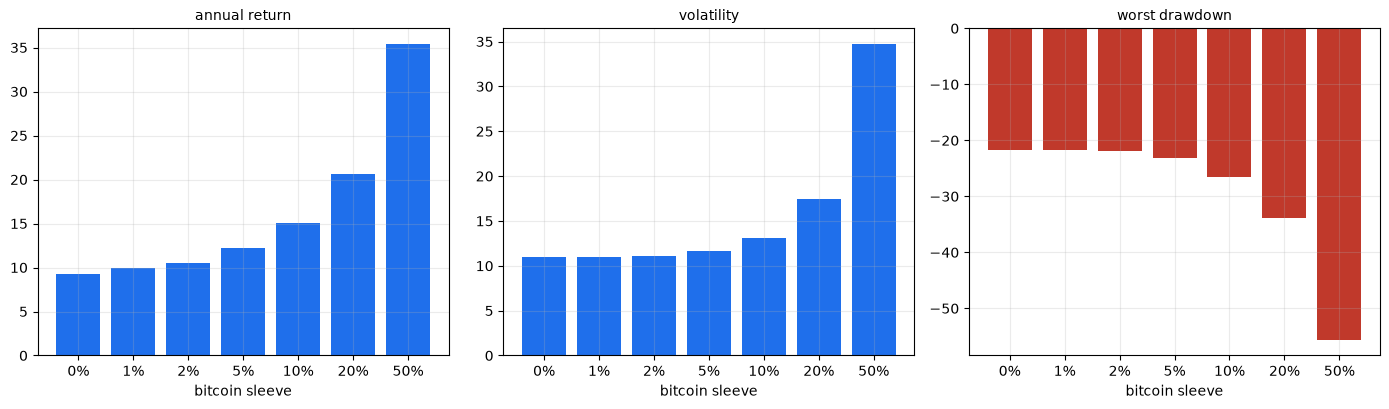

,cagr,vol,sharpe,max_drawdown
weight,,,,
0.0000,0.0931,0.1094,0.8515,-0.2172
0.0100,0.0990,0.1100,0.8995,-0.2177
0.0200,0.1048,0.1110,0.9436,-0.2183
0.0500,0.1221,0.1161,1.0509,-0.2311
0.1000,0.1505,0.1307,1.1514,-0.2651
0.2000,0.2059,0.1747,1.1784,-0.3386
0.5000,0.3541,0.3474,1.0195,-0.5564


In [4]:
sw = st.weight_sweep(base, btc, (0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col, lbl in zip(axes, ["cagr", "vol", "max_drawdown"],
                         ["annual return", "volatility", "worst drawdown"]):
    ax.bar([f"{w:.0%}" for w in sw.index], sw[col] * 100,
           color="#1f6feb" if col != "max_drawdown" else "#c0392b")
    ax.set_title(lbl, fontsize=10); ax.set_xlabel("bitcoin sleeve")
plt.tight_layout(); plt.show()
sw[["cagr", "vol", "sharpe", "max_drawdown"]].round(4)

## 3 · Where is the peak?

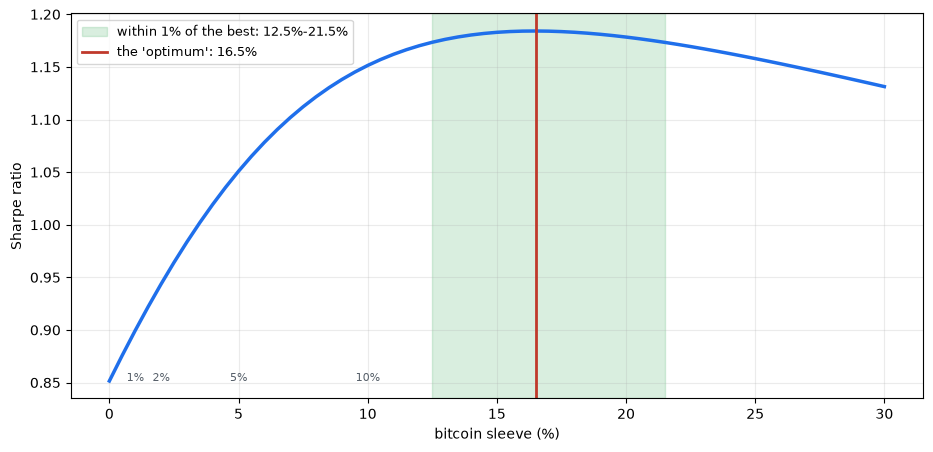

the optimiser's answer: 16.5%
the dotted lines at 1%, 2%, 5% are what allocators actually recommend.
They are nowhere near the peak.


In [5]:
curve = st.objective_curve(base, btc, 0.30, n=61)
f = st.flatness(curve, 0.01)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(curve.index * 100, curve["value"], lw=2.5, color="#1f6feb")
ax.axvspan(f["plateau_lo"] * 100, f["plateau_hi"] * 100, alpha=0.18, color="#2ea44f",
           label=f"within 1% of the best: {f['plateau_lo']:.1%}-{f['plateau_hi']:.1%}")
ax.axvline(f["best_weight"] * 100, color="#c0392b", lw=2,
           label=f"the 'optimum': {f['best_weight']:.1%}")
for w, lbl in ((1, "1%"), (2, "2%"), (5, "5%"), (10, "10%")):
    ax.annotate(lbl, (w, curve["value"].min()), fontsize=8, ha="center", color="#57606a")
ax.set_xlabel("bitcoin sleeve (%)"); ax.set_ylabel("Sharpe ratio")
ax.legend(fontsize=9)
plt.show()
print(f"the optimiser's answer: {f['best_weight']:.1%}")
print(f"the dotted lines at 1%, 2%, 5% are what allocators actually recommend.")
print("They are nowhere near the peak.")

The peak is a long way to the right of every number anyone publishes. That gap is the study.
It is not caused by statistical caution — the next two sections show the data pointing firmly
at the large allocation — so it must be caused by something else.

## 3b · Inverting the question

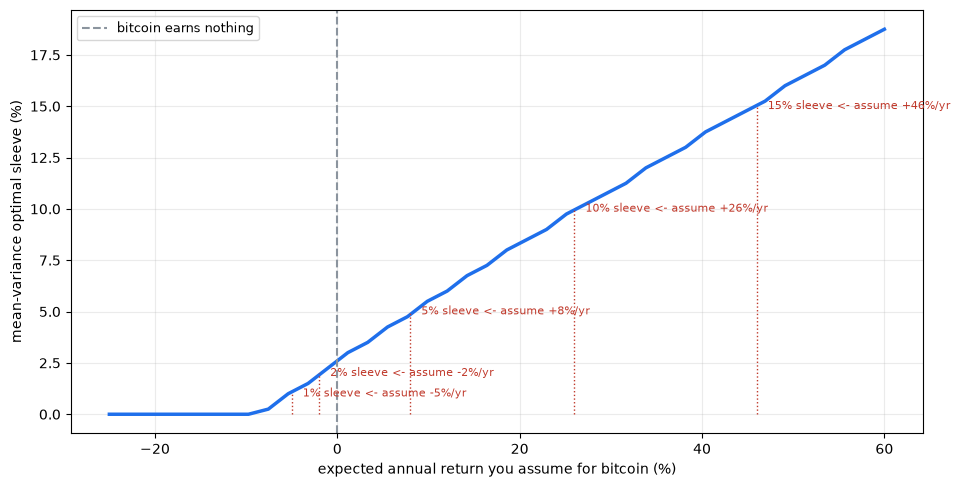

bitcoin actually returned 51% a year over this sample.
        implied_mean  nearest_grid_weight
weight                                   
0.0100       -0.0500               0.0100
0.0200       -0.0200               0.0200
0.0500        0.0800               0.0500
0.1000        0.2600               0.1000
0.1500        0.4600               0.1500


In [6]:
imp = st.implied_mean_for_weight(base, btc, (0.01, 0.02, 0.05, 0.10, 0.15))
realised = np.expm1(np.log1p(btc).sum() * 252 / len(btc))
curve = st.weight_vs_assumed_mean(base, btc, np.linspace(-0.25, 0.60, 40))
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(curve.index * 100, curve["optimal_weight"] * 100, lw=2.5, color="#1f6feb")
for w, row in imp.iterrows():
    ax.plot([row["implied_mean"] * 100, row["implied_mean"] * 100], [0, w * 100],
            color="#c0392b", lw=1, ls=":")
    ax.annotate(f"{w:.0%} sleeve <- assume {row['implied_mean']:+.0%}/yr",
                (row["implied_mean"] * 100, w * 100), fontsize=8,
                xytext=(8, -2), textcoords="offset points", color="#c0392b")
ax.axvline(0, color="#8b949e", lw=1.5, ls="--", label="bitcoin earns nothing")
ax.set_xlabel("expected annual return you assume for bitcoin (%)")
ax.set_ylabel("mean-variance optimal sleeve (%)")
ax.legend(fontsize=9)
plt.show()
print(f"bitcoin actually returned {realised:.0%} a year over this sample.")
print(imp.round(4).to_string())

Read the dashed vertical line. **A 2% bitcoin allocation is the mean-variance answer if you
assume bitcoin's expected return is zero.** A 1% allocation assumes it is *negative*.

That is a perfectly reasonable prior to hold. It is just not a conclusion drawn from the
historical chart printed next to it.

## 4 · Why the override is defensible: the arithmetic of estimating a mean

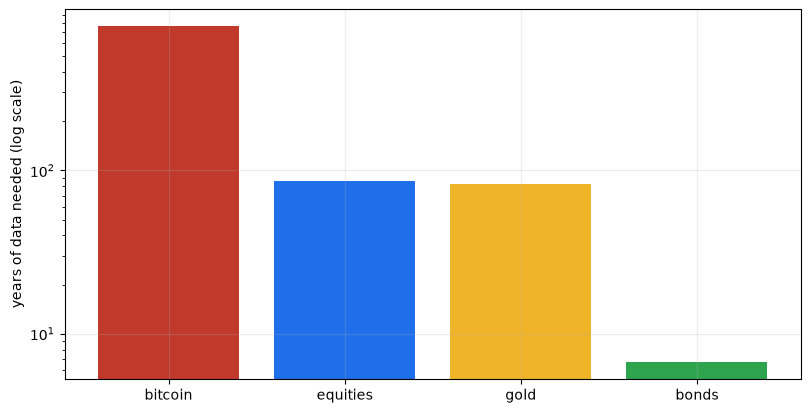

          volatility  years to pin the mean to +/-2pp
asset                                                
bitcoin       0.6000                         764.8000
equities      0.2000                          86.3000
gold          0.2000                          82.7000
bonds         0.1000                           6.7000

The years needed scale with the SQUARE of volatility. Bitcoin is about six times
as volatile as equities, so it needs about thirty-six times the data.


In [7]:
rows = []
for tk, label in ((data.BTC, "bitcoin"), (data.EQUITY, "equities"),
                  (data.GOLD, "gold"), (data.BONDS, "bonds")):
    s = px[tk].dropna().pct_change().dropna()
    vol = s.std(ddof=1) * np.sqrt(252)
    rows.append({"asset": label, "volatility": vol,
                 "years to pin the mean to +/-2pp": st.sample_needed(0, vol, 0.02)
                 ["years_needed"]})
d = pd.DataFrame(rows).set_index("asset")
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.bar(d.index, d["years to pin the mean to +/-2pp"],
       color=["#c0392b", "#1f6feb", "#f0b429", "#2ea44f"])
ax.set_yscale("log"); ax.set_ylabel("years of data needed (log scale)")
plt.show()
print(d.round(1).to_string())
print()
print("The years needed scale with the SQUARE of volatility. Bitcoin is about six times")
print("as volatile as equities, so it needs about thirty-six times the data.")

> \U0001F52C **For the quants.** This is Merton (1980): the standard error of a mean is
> σ/√T and no amount of higher-frequency sampling helps, because σ scales with √T too. Variances
> can be estimated quickly. Means cannot. Optimisers need means.

## 5 · A world where we know the answer

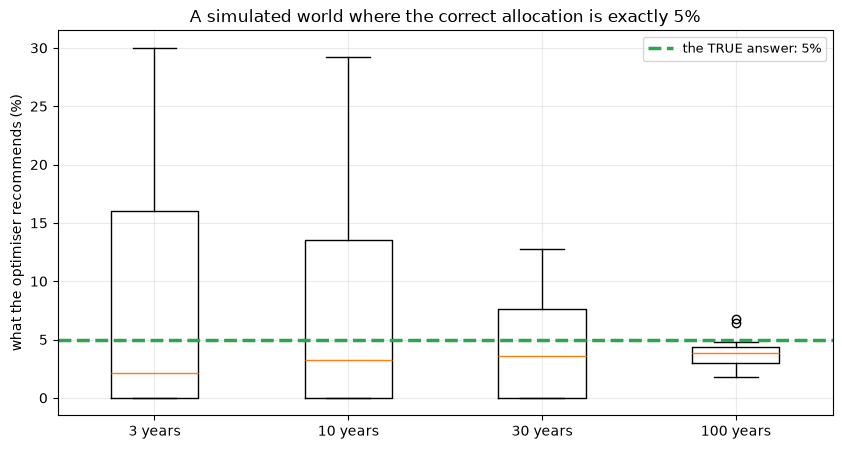

        mean    std    min    max
years                            
3     0.0929 0.1296 0.0000 0.3000
10    0.0839 0.1031 0.0000 0.2925
30    0.0435 0.0433 0.0000 0.1275
100   0.0396 0.0151 0.0180 0.0675


In [8]:
rows = []
for years in (3, 10, 30, 100):
    found = [st.optimal_weight(w["base"], w["asset"], 0.30) for w in
             (st.synthetic_pair(n=int(years * 252), true_weight=0.05, seed=1003 + k)
              for k in range(12))]
    for x in found:
        rows.append({"years": years, "answer": x})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([d[d["years"] == y]["answer"] * 100 for y in (3, 10, 30, 100)],
           tick_labels=["3 years", "10 years", "30 years", "100 years"])
ax.axhline(5.0, color="#2ea44f", lw=2.5, ls="--", label="the TRUE answer: 5%")
ax.set_ylabel("what the optimiser recommends (%)"); ax.legend(fontsize=9)
ax.set_title("A simulated world where the correct allocation is exactly 5%")
plt.show()
print(d.groupby("years")["answer"].agg(["mean", "std", "min", "max"]).round(4).to_string())

Read the 10-year box, which is roughly how much bitcoin history exists. The optimiser is
centred near the truth — it is not biased — and its answers still range across everything from
zero to a fifth of the portfolio.

## 6 · The verdict

**Signal: Real.** Emphatically, in sample. Over 11.8 years to 2026-06-30, a 60/40 returned 9.31% a year at 10.9% volatility, Sharpe 0.85. The Sharpe-maximising bitcoin sleeve was **16.5%** — not 1%, not 2% — lifting the ratio to 1.18 on a 18.68% return, at the cost of a -31.2% maximum drawdown against the base portfolio's -21.7%. That number is what the historical record says, and the gap between it and every published recommendation is the whole subject of this study. One correction along the way: bitcoin trades 365 days a year and the rest of a portfolio does not, so everything here is aligned to the equity calendar; skipping that step changes bitcoin's annualised volatility by 20% and every ratio built on it.

**Tradability: Mirage.** So why does nobody recommend 16%? Because nobody believes the realised mean. Bitcoin returned 51% a year over this sample; inverting the optimiser shows what each published allocation is really assuming. A **1% sleeve is optimal if you expect bitcoin to return -5.0% a year**. A 2% sleeve implies -2.0% — essentially nothing. A 5% sleeve implies +8.0%, about what equities are expected to do. These are not cautious readings of the data; they are the answers you get **after discarding it**, which is a defensible position and an entirely different one from what the accompanying backtests imply. The override is justified by the standard error: at 55% volatility, pinning bitcoin's expected return to ±2 percentage points takes **765 years**, and 12 years leaves a standard error of 16% — so the 51% is not knowledge. Out of sample the walk-forward allocator returned 15.11% against the base portfolio's 10.00%, with its chosen weight swinging from 4.7% to 20.0%. The honest form of a bitcoin recommendation states the expected return it assumes; the weight then follows, and can be argued with.

## 7 · Going further \U0001F6AA

- **Ask what return a recommendation assumes.** Any bitcoin allocation can be converted into
  the expected return that justifies it, and that number is arguable in a way a weight is not.
  If an adviser's 2% implies zero expected return, they are entitled to that view — but then
  the historical chart in the deck is doing no work.
- **The override is defensible.** Section 4 is why: at bitcoin's volatility, its realised
  return is not evidence of its expected return in any useful sense. Discarding the historical
  mean is the right instinct. Presenting the result as though the history supported it is not.
- **Rebalancing decides what you actually own.** A 2% sleeve left alone becomes something much
  larger after a good run. Whatever number you choose, the discipline matters more than the
  number.
- **This generalises to every volatile asset.** For anything with a large σ, the historical
  mean carries almost no information about the future mean, so allocations to it are
  necessarily prior-driven. That is not a criticism; it is a description of what the exercise
  can and cannot be.